<a href="https://colab.research.google.com/github/riyawakde16-art/Day26/blob/main/Day26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Q.1

In [ ]:
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42)
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df


,Feature1,Feature2
0,-8.033836,6.831299
1,-8.767448,-6.918116
2,6.172741,1.407361
3,-2.783673,7.989826
4,-6.038777,-7.165762
...,...,...
495,-7.858779,7.970766
496,-2.563169,9.253093
497,-7.114676,-5.711795
498,-7.245533,-6.145803


In [ ]:
print("First 10 Rows")
df.head(10)

First 10 Rows


,Feature1,Feature2
0,-8.033836,6.831299
1,-8.767448,-6.918116
2,6.172741,1.407361
3,-2.783673,7.989826
4,-6.038777,-7.165762
5,-6.298392,-7.479368
6,-7.046269,7.256281
7,-6.690307,-6.915276
8,3.892545,1.873504
9,-7.317000,-6.861846


In [ ]:
print("\nShape of Dataset")
df.shape


Shape of Dataset


(500, 2)

Q.2

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("\nFirst 5 Rows of Scaled Data")
print(pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"]).head())



First 5 Rows of Scaled Data
   Feature1  Feature2
0 -0.888474  0.629907
1 -1.028908 -1.562875
2  1.831069 -0.235113
3  0.116557  0.814671
4 -0.506563 -1.602370


Q.3

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)
print("\nDataset with Cluster Labels")
print(df.head(10))


Dataset with Cluster Labels
   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


Q.4

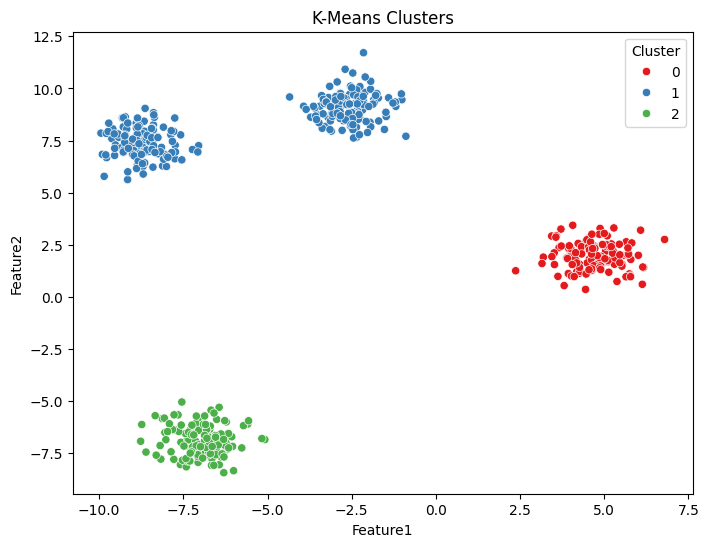

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Cluster",
    palette="Set1")
plt.title("K-Means Clusters")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()


Q.5

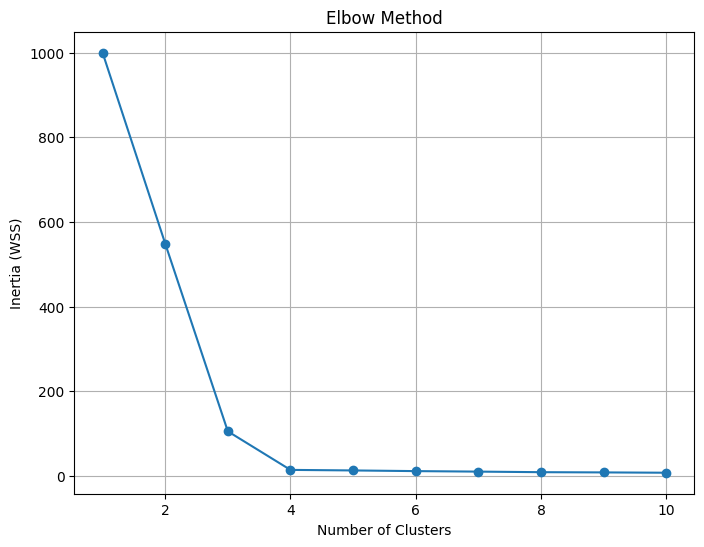


From the graph, choose the elbow point as the optimal K.


In [ ]:
wss = []
for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wss.append(model.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1,11), wss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (WSS)")
plt.grid(True)
plt.show()
print("\nFrom the graph, choose the elbow point as the optimal K.")

Q.6

In [ ]:
optimal_k = 4
final_model = KMeans(
    n_clusters=optimal_k,
    random_state=42)
df["Final_Cluster"] = final_model.fit_predict(X_scaled)
print("\nCluster Counts")
print(df["Final_Cluster"].value_counts())



Cluster Counts
Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


Q.7

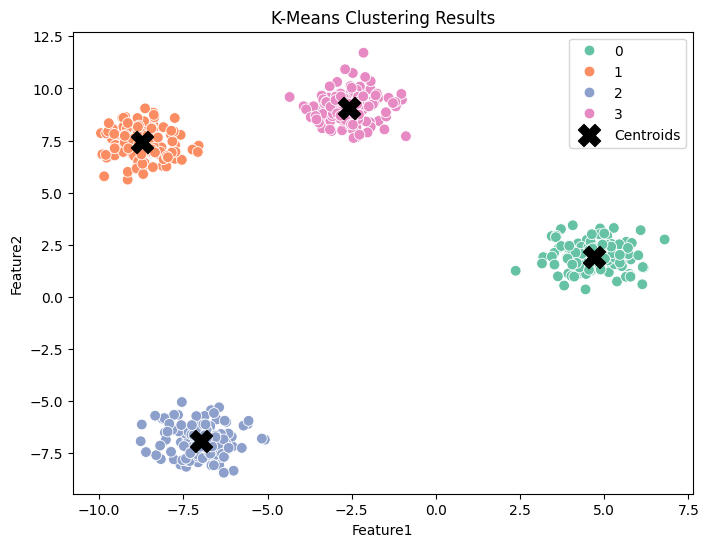

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Final_Cluster",
    palette="Set2",
    s=60)
centers = scaler.inverse_transform(final_model.cluster_centers_)
plt.scatter(
    centers[:,0],
    centers[:,1],
    c="black",
    marker="X",
    s=250,
    label="Centroids")
plt.title("K-Means Clustering Results")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.show()


Q.8

In [ ]:
iris = load_iris()
iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names)
print("\nFirst 5 Rows of Iris Dataset")
print(iris_df.head())
scaler2 = StandardScaler()
iris_scaled = scaler2.fit_transform(iris_df)
kmeans2 = KMeans(
    n_clusters=3,
    random_state=42)
iris_df["Cluster"] = kmeans2.fit_predict(iris_scaled)
print("\nCluster Counts")
print(iris_df["Cluster"].value_counts())


First 5 Rows of Iris Dataset
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Cluster Counts
Cluster
0    96
1    33
2    21
Name: count, dtype: int64


Q.9

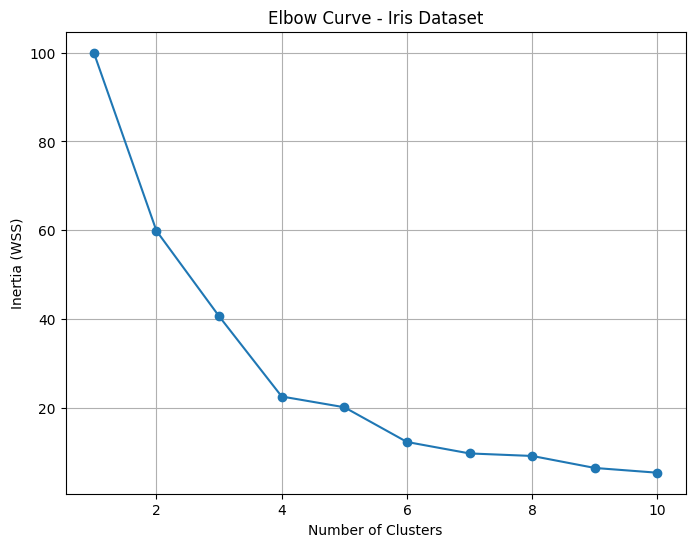

Choose the optimal K from the elbow graph.


In [29]:
wss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wss.append(model.inertia_)
# Plot Elbow Curve
plt.figure(figsize=(8,6))
plt.plot(range(1,11), wss, marker='o')
plt.title("Elbow Curve - Iris Dataset")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (WSS)")
plt.grid(True)
plt.show()
print("Choose the optimal K from the elbow graph.")


Cluster Counts:
Cluster
1    11
2     7
0     2
Name: count, dtype: int64


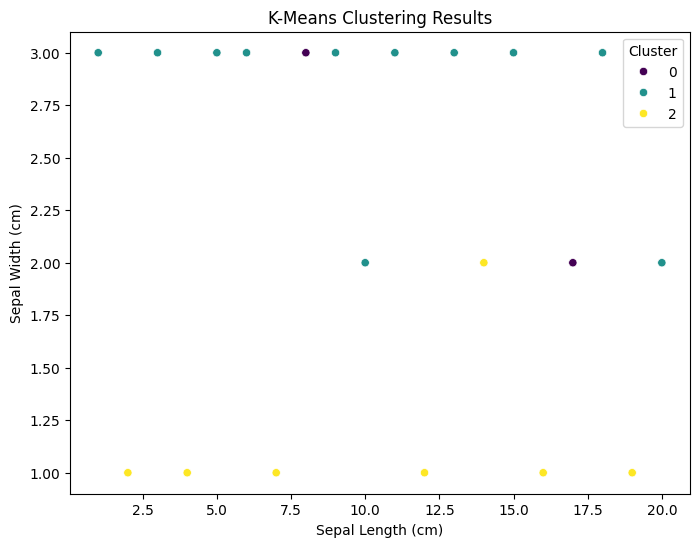

In [30]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)
print("\nCluster Counts:")
print(df["Cluster"].value_counts())
# Cluster Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df.iloc[:,0],      # Sepal Length
    y=df.iloc[:,1],      # Sepal Width
    hue=df["Cluster"],
    palette="viridis")
plt.title("K-Means Clustering Results")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()

Q.10

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google.colab import files
uploaded=files.upload()

Saving titanic_dataset.csv to titanic_dataset.csv


In [ ]:
 #1. Load and Explore the Data

df = pd.read_csv("titanic_dataset.csv")
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   PassengerId  Pclass     Sex  Age  SibSp  Parch     Fare Embarked  Survived
0            1       3    male   22      1      0   7.2500        S         0
1            2       1  female   38      1      0  71.2833        C         1
2            3       3  female   26      0      0   7.9250        S         1
3            4       1  female   35      1      0  53.1000        S         1
4            5       3    male   35      0      0   8.0500        S         0

Dataset Shape:
(20, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  20 non-null     int64  
 1   Pclass       20 non-null     int64  
 2   Sex          20 non-null     object 
 3   Age          20 non-null     int64  
 4   SibSp        20 non-null     int64  
 5   Parch        20 non-null     int64  
 6   Fare         20 non-null     

In [ ]:
# 2. Select Numerical Features and Scale Them
X = df[["Pclass", "Age", "SibSp", "Parch", "Fare"]]
# Fill missing values (if any)
X = X.fillna(X.mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X

,Pclass,Age,SibSp,Parch,Fare
0,3,22,1,0,7.2500
1,1,38,1,0,71.2833
2,3,26,0,0,7.9250
3,1,35,1,0,53.1000
4,3,35,0,0,8.0500
5,3,27,0,0,8.4583
6,1,54,0,0,51.8625
7,3,2,3,1,21.0750
8,3,27,0,2,11.1333
9,2,14,1,0,30.0708


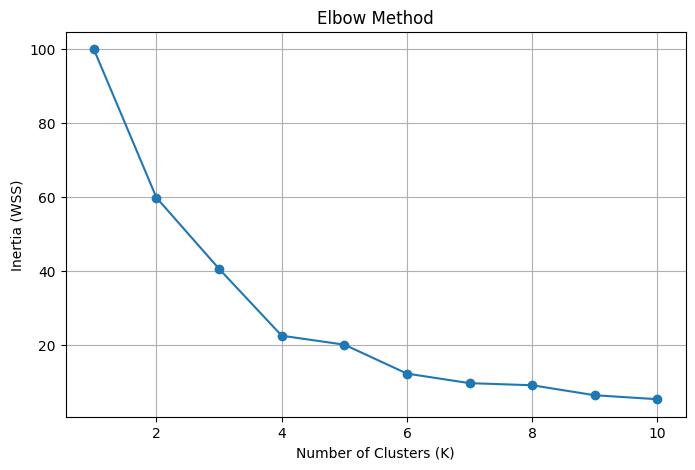

From the elbow graph, choose the optimal K.


In [ ]:
# 3. Apply Elbow Method
wss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wss.append(model.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
plt.grid(True)
plt.show()
print("From the elbow graph, choose the optimal K.")
optimal_k = 3      # Change this if your elbow graph suggests another K

In [ ]:
# 4. Train Final KMeans Model
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)
print("\nCluster Sizes:")
print(df["Cluster"].value_counts())


Cluster Sizes:
Cluster
1    11
2     7
0     2
Name: count, dtype: int64


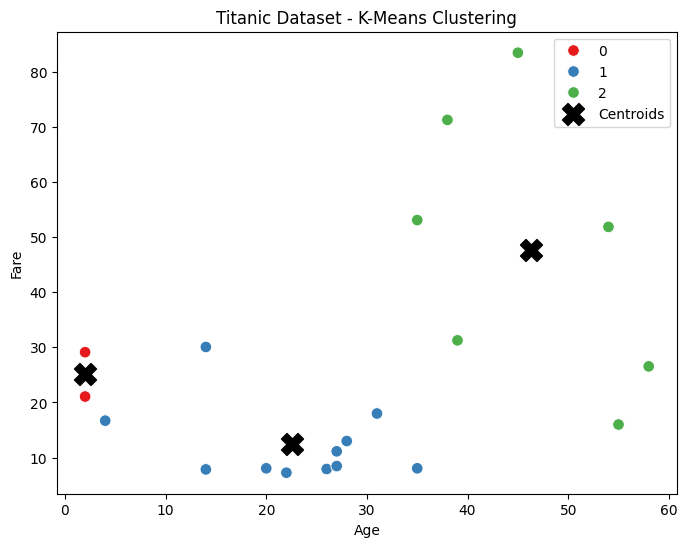


Mini Project Completed Successfully!


In [ ]:
# 5. Visualize the Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Cluster",
    palette="Set1",
    s=70)
# Plot Cluster Centroids
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:,1],      # Age
    centers[:,4],      # Fare
    c="black",
    marker="X",
    s=250,
    label="Centroids")
plt.title("Titanic Dataset - K-Means Clustering")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend()
plt.show()
print("\nMini Project Completed Successfully!")